# Exploración vs Explotación - Snake Game

Ahora elegimos entre **4 direcciones** para mover la serpiente:
- 0 = Arriba
- 1 = Derecha  
- 2 = Abajo
- 3 = Izquierda

Cada dirección tiene un valor $q_*(a)$ que depende de si nos acerca a la comida o nos lleva a una colisión.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulamos los valores de cada dirección (similar a los topos)
# En Snake, estos valores cambian según la posición de la comida
np.random.seed(42)

# Valores base para cada dirección (0=Arriba, 1=Derecha, 2=Abajo, 3=Izquierda)
q = {k: v for k, v in enumerate(np.random.normal(0, 1, 4))}
print("Valores de cada dirección:")
direcciones = ['Arriba ↑', 'Derecha →', 'Abajo ↓', 'Izquierda ←']
for k, nombre in enumerate(direcciones):
    print(f"{nombre}: {q[k]:.3f}")

Valores de cada dirección:
Arriba ↑: 0.497
Derecha →: -0.138
Abajo ↓: 0.648
Izquierda ←: 1.523


## Métodos de acción-valor: ε-greedy en Snake

Ahora probamos diferentes valores de $\epsilon$ para ver cómo afecta al aprendizaje en Snake.

In [6]:
partidas = 1000
movimientos = 100  # En lugar de turnos, ahora son movimientos
epsilons = [0, 0.01, 0.1]
recompensas_medias = np.zeros((len(epsilons), movimientos))
acciones_optimas = np.zeros((len(epsilons), movimientos))

for partida in range(partidas):
    mejor_direccion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(4)}  # 4 direcciones en lugar de 5 topos
        movimientos_realizados = {k: 0 for k in range(4)}
        recompensas = {k: 0 for k in range(4)}
        for mov in range(movimientos):
            # elegir dirección
            if np.random.uniform(0,1) < e:
                # dirección aleatoria
                direccion = np.random.randint(4)
            else:
                # dirección con mayor valor
                maxQ = -100
                for j in range(4):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        direccion = j
            movimientos_realizados[direccion] += 1
            recompensa = q[direccion]
            recompensas[direccion] += recompensa
            Q[direccion] = recompensas[direccion]/movimientos_realizados[direccion]
            recompensas_medias[i][mov] += recompensa
            acciones_optimas[i][mov] += (direccion == mejor_direccion)

recompensas_medias /= partidas
acciones_optimas /= partidas

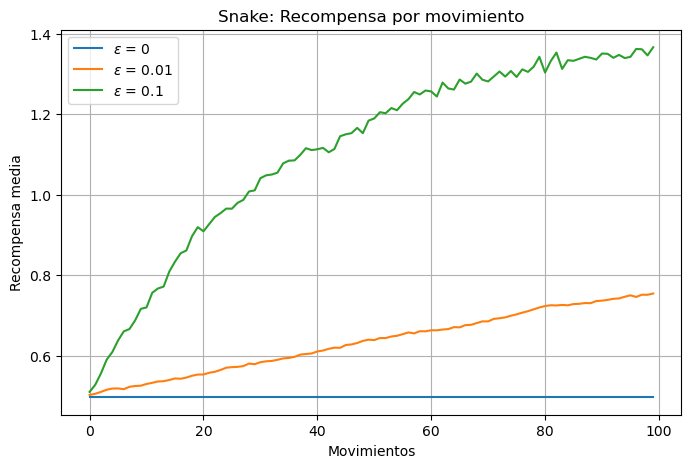

In [7]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Movimientos')
plt.ylabel('Recompensa media')
plt.title('Snake: Recompensa por movimiento')
plt.show()

## Implementación incremental en Snake

In [8]:
partidas = 1000
movimientos = 100
alpha = 0.5
epsilons = [0., 0.01, 0.1]
recompensas_medias = np.zeros((len(epsilons), movimientos))
acciones_optimas = np.zeros((len(epsilons), movimientos))

for partida in range(partidas):
    mejor_direccion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(4)}
        for mov in range(movimientos):
            # elegir dirección
            if np.random.uniform(0,1) < e:
                # dirección aleatoria
                direccion = np.random.randint(4)
            else:
                # dirección con mayor valor
                maxQ = -100
                for j in range(4):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        direccion = j
            recompensa = q[direccion]
            Q[direccion] += alpha*(recompensa - Q[direccion])
            recompensas_medias[i][mov] += recompensa
            acciones_optimas[i][mov] += (direccion == mejor_direccion)

recompensas_medias /= partidas
acciones_optimas /= partidas

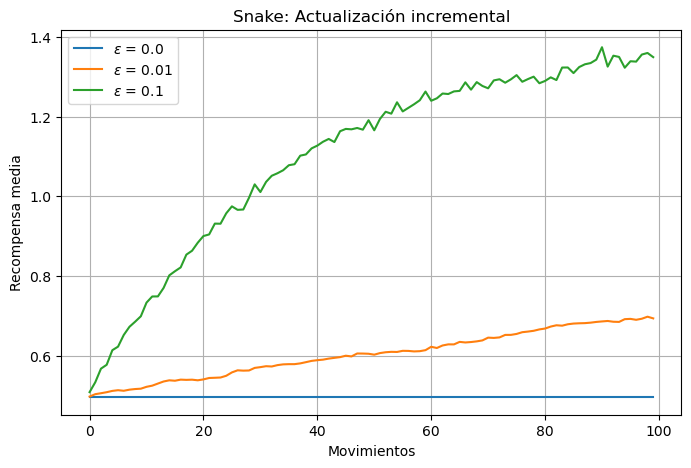

In [9]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Movimientos')
plt.ylabel('Recompensa media')
plt.title('Snake: Actualización incremental')
plt.show()

## Valores iniciales optimistas en Snake

In [10]:
partidas = 1000
movimientos = 100
alpha=0.5
epsilons = [0, 0.1]
recompensas_medias = np.zeros((len(epsilons), movimientos))
acciones_optimas = np.zeros((len(epsilons), movimientos))

for partida in range(partidas):
    mejor_direccion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(4)}
        # inicializamos a valores altos si el agente es greedy
        if e == 0:
            Q = {k: 5 for k in range(4)}
        for mov in range(movimientos):
            # elegir dirección
            if np.random.uniform(0,1) < e:
                # dirección aleatoria
                direccion = np.random.randint(4)
            else:
                # dirección con mayor valor
                maxQ = -100
                for j in range(4):
                    if Q[j] > maxQ:
                        maxQ = Q[j]
                        direccion = j
            recompensa = q[direccion]
            Q[direccion] += alpha*(recompensa - Q[direccion])
            recompensas_medias[i][mov] += recompensa
            acciones_optimas[i][mov] += (direccion == mejor_direccion)

recompensas_medias /= partidas
acciones_optimas /= partidas

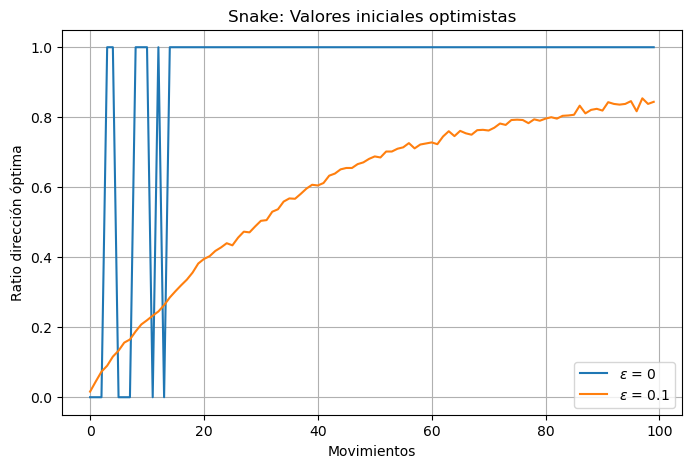

In [11]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(acciones_optimas[i], label=f'$\epsilon$ = {e}')
plt.legend()
plt.grid(True)
plt.xlabel('Movimientos')
plt.ylabel('Ratio dirección óptima')
plt.title('Snake: Valores iniciales optimistas')
plt.show()

## Selección de direcciones con UCB (Upper Confidence Bound)

In [12]:
import math

partidas = 1000
movimientos = 100
alpha=0.5
c = 1
epsilons = [0.1, 0.5]
recompensas_medias = np.zeros((len(epsilons), movimientos))
acciones_optimas = np.zeros((len(epsilons), movimientos))

for partida in range(partidas):
    mejor_direccion = max(q, key=q.get)
    for i, e in enumerate(epsilons):
        Q = {k: 0 for k in range(4)}
        movimientos_realizados = {k: 1 for k in range(4)}
        for mov in range(movimientos):
            if i == 0: # UCB
                maxQ = -100
                for j in range(4):
                    A = Q[j] + c*math.sqrt(math.log(mov+1)/(movimientos_realizados[j]))
                    if A > maxQ:
                        maxQ = A
                        direccion = j
            else:
                # elegir dirección
                if np.random.uniform(0,1) < e:
                    # dirección aleatoria
                    direccion = np.random.randint(4)
                else:
                    # dirección con mayor valor
                    maxQ = -100
                    for j in range(4):
                        if Q[j] > maxQ:
                            maxQ = Q[j]
                            direccion = j
            movimientos_realizados[direccion] += 1
            recompensa = q[direccion]
            Q[direccion] += alpha*(recompensa - Q[direccion])
            recompensas_medias[i][mov] += recompensa
            acciones_optimas[i][mov] += (direccion == mejor_direccion)

recompensas_medias /= partidas
acciones_optimas /= partidas

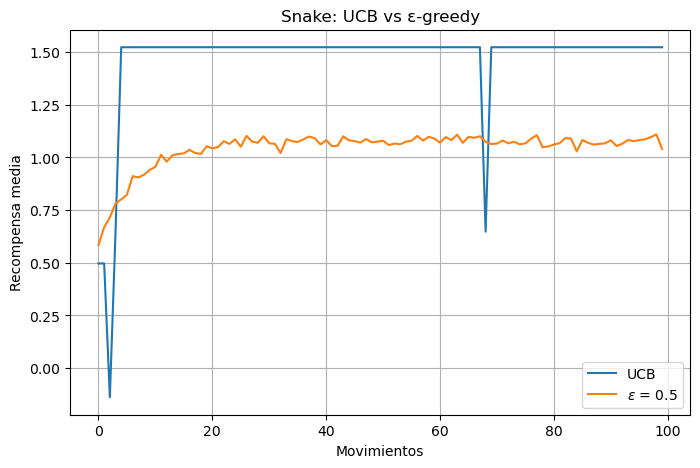

In [13]:
plt.figure(figsize=(8,5))
for i, e in enumerate(epsilons):
    plt.plot(recompensas_medias[i], label=f'$\epsilon$ = {e}' if i != 0 else "UCB")
plt.legend()
plt.grid(True)
plt.xlabel('Movimientos')
plt.ylabel('Recompensa media')
plt.title('Snake: UCB vs ε-greedy')
plt.show()

## Algoritmos de Gradiente para Snake

En lugar de estimar valores, asignamos preferencias a cada dirección.

In [14]:
def softmax(x):
    return np.exp(x)/sum(np.exp(x))

In [15]:
partidas = 1000
movimientos = 100
alphas = [0.1, 0.4]
recompensas_medias = np.zeros((len(alphas), movimientos))
acciones_optimas = np.zeros((len(alphas), movimientos))

for partida in range(partidas):
    mejor_direccion = max(q, key=q.get)
    for i, alpha in enumerate(alphas):
        H = np.zeros(4)  # 4 direcciones
        pi = softmax(H)
        recompensas = []
        for mov in range(movimientos):
            # elegir dirección
            direccion = np.random.choice(range(4), 1, p=pi)[0]
            recompensa = q[direccion]
            recompensas.append(recompensa)
            recompensa_media = np.mean(recompensas)
            # actualizar preferencias
            for j in range(4):
                if j == direccion:
                    H[j] += alpha*(recompensa - recompensa_media)*(1-pi[j])
                else:
                    H[j] -= alpha*(recompensa - recompensa_media)*pi[j]
            # actualizar probabilidades
            pi = softmax(H)
            recompensas_medias[i][mov] += recompensa
            acciones_optimas[i][mov] += (direccion == mejor_direccion)

recompensas_medias /= partidas
acciones_optimas /= partidas

c:\Users\HP\anaconda3\envs\pytorch_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128013 (\N{SNAKE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


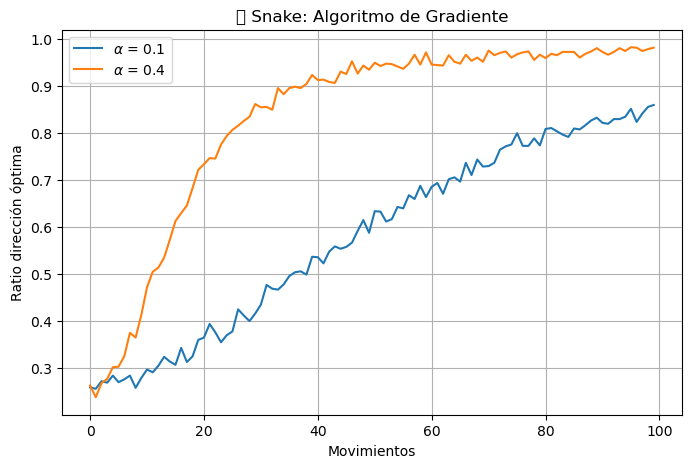

In [16]:
plt.figure(figsize=(8,5))
for i, a in enumerate(alphas):
    plt.plot(acciones_optimas[i], label=fr'$\alpha$ = {a}')
plt.legend()
plt.grid(True)
plt.xlabel('Movimientos')
plt.ylabel('Ratio dirección óptima')
plt.title('🐍 Snake: Algoritmo de Gradiente')
plt.show()